# Pipeline Nhan Dien Bien So Xe
## Do an mon Xu ly Anh va Thi giac May tinh

**Cac buoc pipeline:**
```
Anh xe -> YOLO -> Crop -> Grayscale -> CLAHE -> Bilateral+Unsharp
       -> Adaptive Threshold -> Morphology -> Segment
       -> HOG features -> kNN -> Bien so hoan chinh
```
> Sau moi buoc deu co hien thi ket qua truc quan.

## Cell 1 - Import thu vien va cau hinh

In [43]:
import os, sys, cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

ROOT_DIR = os.path.abspath(".")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.yolo_detector import YOLODetector
from src.preprocess import (
    resize_if_small, percentile_stretch, auto_gamma,
    unsharp_mask, choose_threshold, apply_morphology,
)
from src.segment import segment_with_contour
from src.hog_feature import compute_hog_features
from src.knn_classifier import load_knn_model, predict_characters

YOLO_MODEL = os.path.join(ROOT_DIR, "models", "run_1", "weights", "best.pt")
KNN_MODEL  = os.path.join(ROOT_DIR, "models", "knn_hog_model.joblib")

print("Import OK!")
print(f"YOLO: {YOLO_MODEL}")
print(f"kNN : {KNN_MODEL}")

Import OK!
YOLO: d:\SmartParkingCV\models\run_1\weights\best.pt
kNN : d:\SmartParkingCV\models\knn_hog_model.joblib


## Cell 2 - Ham tien ich hien thi anh

In [44]:
def bgr2rgb(img):
    if len(img.shape) == 2: return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_one(title, image, cmap=None, figsize=(8,4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(bgr2rgb(image) if cmap is None else image, cmap=cmap)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    fig.tight_layout()
    plt.show()

def show_grid(items, suptitle='', cols=3, cw=4, ch=3):
    n = len(items)
    if not n: return
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*cw, rows*ch))
    axes = np.array(axes).flatten()
    for i, (t, img, cmap) in enumerate(items):
        axes[i].imshow(bgr2rgb(img) if cmap is None else img, cmap=cmap)
        axes[i].set_title(t, fontsize=10, fontweight='bold')
        axes[i].axis('off')
    for j in range(n, len(axes)): axes[j].axis('off')
    if suptitle: fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()

print('Ham hien thi da san sang.')

Ham hien thi da san sang.


## Buoc 0 - Doc anh xe dau vao
> **Doi bien `IMAGE_PATH`** thanh duong dan anh ban muon test.

Anh: valid\images\xemayBigPlate233_jpg.rf.aefcc982e319ce5613b21d157eec9e95.jpg
Kich thuoc: 640x512 px


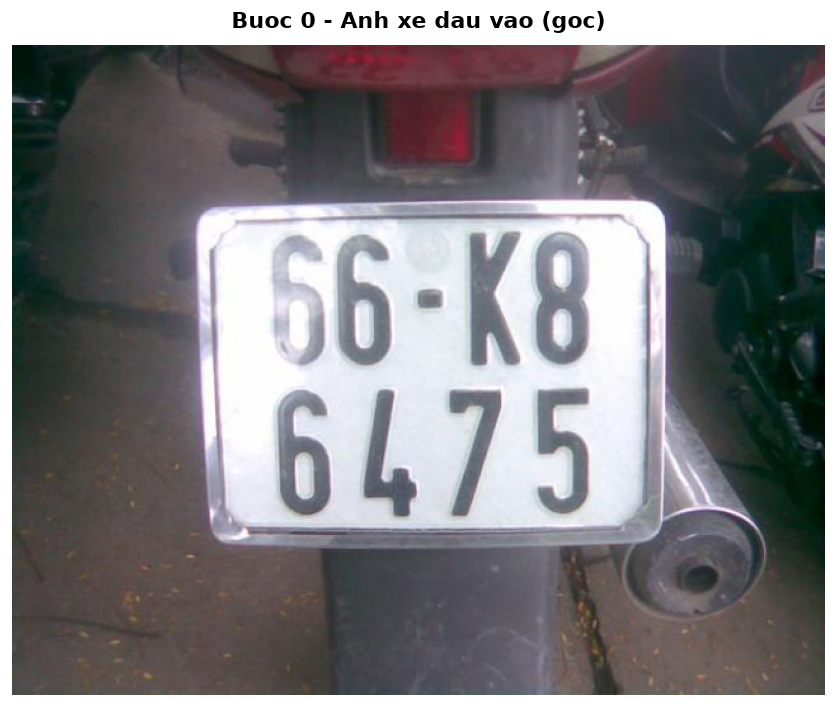

In [45]:
# ===== THAY DOI DUONG DAN ANH O DAY =====
IMAGE_PATH = r"valid\images\xemayBigPlate233_jpg.rf.aefcc982e319ce5613b21d157eec9e95.jpg"
# ==========================================

if not os.path.exists(IMAGE_PATH):
    for d in [os.path.join(ROOT_DIR,'valid','images'), os.path.join(ROOT_DIR,'dataset','images')]:
        if os.path.isdir(d):
            imgs = [f for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                IMAGE_PATH = os.path.join(d, imgs[0])
                print(f'[INFO] Dung anh demo: {IMAGE_PATH}')
                break

img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f'Khong doc duoc: {IMAGE_PATH}'

print(f'Anh: {IMAGE_PATH}')
print(f'Kich thuoc: {img_bgr.shape[1]}x{img_bgr.shape[0]} px')

show_one('Buoc 0 - Anh xe dau vao (goc)', img_bgr, figsize=(10,6))

## Buoc 1 - YOLO: Phat hien bien so xe
YOLO chay inference, ve bounding box va hien thi confidence cho tung vung bien so.

In [ ]:
yolo_path = YOLO_MODEL if os.path.exists(YOLO_MODEL) else 'yolov8n.pt'
if not os.path.exists(YOLO_MODEL):
    print('[CANH BAO] Khong tim thay model rieng, dung pretrained yolov8n.pt')

detector = YOLODetector(model_path=yolo_path, conf_threshold=0.25, iou_threshold=0.45, imgsz=640)

detections = detector.detect(img_bgr)
print(f'Phat hien: {len(detections)} bien so')
for i, d in enumerate(detections):
    print(f'  #{i+1}: bbox={d["bbox"]}  conf={d["confidence"]:.3f}')

img_detected = detector.detect_and_draw(img_bgr)

show_grid(
    [('Anh goc', img_bgr, None), ('Buoc 1 - YOLO: Bounding box + Conf', img_detected, None)],
    suptitle='Buoc 1: YOLO phat hien bien so xe',
    cols=2, cw=8, ch=5
)

## Buoc 2 - Crop: Cat vung bien so
Chon vung co confidence cao nhat, them padding 5%.

In [ ]:
plate_crop, conf = detector.crop_plate(img_bgr, padding_ratio=0.05)
assert plate_crop is not None, 'Crop that bai!'
h_c, w_c = plate_crop.shape[:2]
print(f'Crop: {w_c}x{h_c} px  |  Confidence: {conf:.3f}')

show_grid(
    [('Anh goc (full)', img_bgr, None), ('Buoc 2 - Crop: Vung bien so', plate_crop, None)],
    suptitle='Buoc 2: Cat vung bien so tu anh goc',
    cols=2, cw=7, ch=4
)

## Buoc 3 - Grayscale: Chuyen sang anh xam
Resize len neu chieu cao < 180px, sau do chuyen BGR -> Gray.

In [ ]:
resized, scale = resize_if_small(plate_crop, target_height=180)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
print(f'Sau resize: {resized.shape[1]}x{resized.shape[0]}px  (scale={scale:.2f})')

show_grid(
    [('Crop goc (mau)', plate_crop, None),
     (f'Sau resize (scale={scale:.2f})', resized, None),
     ('Buoc 3 - Grayscale', gray, 'gray')],
    suptitle='Buoc 3: Chuyen sang anh xam',
    cols=3, cw=5, ch=3
)

## Buoc 4 - CLAHE: Tang cuong tuong phan cuc bo
1. **Percentile Stretch** - Gian tuong phan, loai diem bat thuong
2. **Auto Gamma** - Chinh sang tu dong (toi hon -> gamma<1, sang hon -> gamma>1)
3. **CLAHE** (clip_limit=2.0) - Can bang histogram cuc bo tren cac o 8x8

In [ ]:
stretched = percentile_stretch(gray, low=2, high=98)
gamma_img, gamma_val = auto_gamma(stretched)
clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gamma_img)

print(f'Gamma ap dung: {gamma_val:.2f}')
print(f'Tuong phan (std) truoc: {np.std(gray):.2f}  ->  sau: {np.std(enhanced):.2f}')

show_grid(
    [('Grayscale (goc)', gray, 'gray'),
     ('Percentile Stretch', stretched, 'gray'),
     (f'Auto Gamma (g={gamma_val:.2f})', gamma_img, 'gray'),
     ('Buoc 4 - CLAHE (clip=2.0)', enhanced, 'gray')],
    suptitle='Buoc 4: CLAHE - Tang cuong tuong phan cuc bo',
    cols=4, cw=4, ch=3
)

## Buoc 5 - Bilateral Filter + Unsharp Mask
- **Bilateral**: Lam mo de giam nhieu **nhung giu lai canh** (khac Gaussian blur)
- **Unsharp Mask**: Tang net net chu bang ky thuat subtraction

In [ ]:
denoised = cv2.bilateralFilter(enhanced, d=5, sigmaColor=45, sigmaSpace=45)
sharp    = unsharp_mask(denoised, amount=1.1, sigma=1.0)
print('Bilateral: d=5, sigmaColor=45, sigmaSpace=45')
print('Unsharp  : amount=1.1, sigma=1.0')

show_grid(
    [('Sau CLAHE', enhanced, 'gray'),
     ('Bilateral Filter (khu nhieu)', denoised, 'gray'),
     ('Buoc 5 - Unsharp Mask (lam net)', sharp, 'gray')],
    suptitle='Buoc 5: Bilateral Filter + Unsharp Mask',
    cols=3, cw=5, ch=3
)

## Buoc 6 - Adaptive Threshold: Nhi phan hoa anh
Ham `choose_threshold(method='auto')` thu 4 phuong phap (Otsu, Adaptive 21/31/41)
va chon phuong phap tot nhat theo ti le pixel trang hop ly (~28%).

In [ ]:
chosen_name, binary, all_candidates = choose_threshold(sharp, method='auto')
print(f'Phuong phap tu dong chon: {chosen_name}')
print(f'Ti le pixel trang: {np.count_nonzero(binary)/binary.size*100:.1f}%')

# So sanh tat ca phuong phap
show_grid(
    [(name, img, 'gray') for name, img in all_candidates.items()],
    suptitle='Buoc 6: So sanh cac phuong phap Threshold (Otsu vs Adaptive)',
    cols=min(len(all_candidates), 4), cw=4, ch=3
)

# Hien thi rieng ket qua da chon
show_one(f'Buoc 6 - Threshold da chon: [{chosen_name}]', binary, cmap='gray', figsize=(9,4))

## Buoc 7 - Morphology: Lam sach nhieu nho
**Morphological Open** -> **Close** voi kernel 2x2:
- Open: Xoa nhieu li ti (< 2px)
- Close: Lap day lo trong than chu

In [ ]:
morph = apply_morphology(binary, kernel_size=2)
print(f'Kernel: 2x2 RECT | Open -> Close')
print(f'Pixel trang truoc: {np.count_nonzero(binary)/binary.size*100:.2f}%')
print(f'Pixel trang sau : {np.count_nonzero(morph)/morph.size*100:.2f}%')

show_grid(
    [('Sau Threshold (co nhieu)', binary, 'gray'),
     ('Buoc 7 - Sau Morphology (sach hon)', morph, 'gray')],
    suptitle='Buoc 7: Morphology (Open+Close) - Lam sach nhieu nho',
    cols=2, cw=6, ch=4
)

## Buoc 8 - Segment: Tach tung ky tu
Tim contour, loc theo `min_area=40` va `aspect_ratio=(0.2, 1.6)`.
> Tham so toi uu tu khao sat thuc nghiem trong `scripts/yolo_preprocess_seg_survey.py`.

In [ ]:
char_data = segment_with_contour(morph, min_area=40, aspect_ratio_range=(0.2,1.6), row_threshold=10, pad_char=2)
n_chars = len(char_data)
print(f'Tach duoc: {n_chars} ky tu')
for i, (cimg, bbox) in enumerate(char_data):
    print(f'  #{i+1}: bbox={bbox}  size={cimg.shape[1]}x{cimg.shape[0]}')

# Ve bbox len anh
morph_rgb = cv2.cvtColor(morph, cv2.COLOR_GRAY2BGR)
for idx, (_, (cx,cy,cw,ch)) in enumerate(char_data):
    cv2.rectangle(morph_rgb, (cx,cy), (cx+cw,cy+ch), (0,255,0), 2)
    cv2.putText(morph_rgb, str(idx+1), (cx, cy-4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,255), 1)

show_one(f'Buoc 8 - Segment: {n_chars} ky tu (bbox xanh la)', morph_rgb, figsize=(10,4))

if char_data:
    show_grid(
        [(f'Char #{i+1}', cimg, 'gray') for i,(cimg,_) in enumerate(char_data)],
        suptitle=f'Buoc 8: Tung ky tu da tach ({n_chars} ky tu)',
        cols=min(n_chars,10), cw=2, ch=2.5
    )

## Buoc 9 - HOG: Trich xuat dac trung
Moi ky tu: resize 48x48 -> HOG vector 54 chieu.
HOG nam bat huong gradient (ngang/doc/cheo) de phan biet cac ky tu.

In [ ]:
from skimage.feature import hog as sk_hog

VIS_P  = dict(orientations=6, pixels_per_cell=(8,8), cells_per_block=(1,1), visualize=True)
FEAT_P = dict(orientations=6, pixels_per_cell=(8,8), cells_per_block=(1,1), visualize=False)

all_chars = [cimg for cimg,_ in char_data]
sample_r  = cv2.resize(all_chars[0], (48,48))
feat_s, hog_vis = sk_hog(sample_r, **VIS_P)

print(f'HOG params: orientations=6, pixels_per_cell=(8,8), cells_per_block=(1,1)')
print(f'Vector HOG: {len(feat_s)} chieu / ky tu')

show_grid(
    [('Ky tu #1 (48x48)', sample_r, 'gray'),
     ('Buoc 9 - HOG Visualization', hog_vis, 'gray')],
    suptitle='Buoc 9: HOG - Histogram of Oriented Gradients',
    cols=2, cw=5, ch=5
)

# Trich xuat HOG cho tat ca ky tu
hog_feats = np.array([sk_hog(cv2.resize(c,(48,48)), **FEAT_P) for c in all_chars])
print(f'Ma tran HOG: {hog_feats.shape}  ({hog_feats.shape[0]} ky tu x {hog_feats.shape[1]} chieu)')

fig, ax = plt.subplots(figsize=(12,3))
im = ax.imshow(hog_feats, aspect='auto', cmap='viridis')
ax.set_xlabel('Chieu dac trung HOG'); ax.set_ylabel('Ky tu #')
ax.set_yticks(range(n_chars)); ax.set_yticklabels([f'#{i+1}' for i in range(n_chars)])
ax.set_title('Buoc 9 - Ma tran HOG features (moi hang = 1 ky tu)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## Buoc 10 - kNN: Nhan dang ky tu
Mo hinh kNN (k=1) duoc huan luyen voi HOG features 54 chieu tren tap anh ky tu 48x48.

In [ ]:
assert os.path.exists(KNN_MODEL), f'Khong tim thay model: {KNN_MODEL}'
knn = load_knn_model(KNN_MODEL)

preds = predict_characters(knn, all_chars)
print('Ket qua nhan dang:')
for i, p in enumerate(preds):
    print(f'  Char #{i+1}: [{p}]')

show_grid(
    [(f'#{i+1}: "{p}"', cimg, 'gray') for i,(cimg,p) in enumerate(zip(all_chars,preds))],
    suptitle='Buoc 10 - kNN: Nhan dang tung ky tu (k=1)',
    cols=min(n_chars,10), cw=2, ch=2.5
)

## Buoc 11 - Bien so hoan chinh & Tong ket Pipeline
Ghep tat ca ky tu nhan dang duoc thanh chuoi bien so cuoi cung.

In [ ]:
plate = ''.join(preds)
print('='*50)
print(f'  BIEN SO NHAN DIEN DUOC: {plate}')
print('='*50)

# Tong hop toan pipeline
steps = [
    ('0. Anh goc', img_bgr, None),
    ('1. YOLO', img_detected, None),
    ('2. Crop', plate_crop, None),
    ('3. Grayscale', gray, 'gray'),
    ('4. CLAHE', enhanced, 'gray'),
    ('5. Bilateral+Sharp', sharp, 'gray'),
    ('6. Threshold', binary, 'gray'),
    ('7. Morphology', morph, 'gray'),
    ('8. Segment', morph_rgb, None),
]
fig, axes = plt.subplots(1, len(steps), figsize=(len(steps)*3.2, 3.8))
for ax, (t, img, cm) in zip(axes, steps):
    ax.imshow(bgr2rgb(img) if cm is None else img, cmap=cm)
    ax.set_title(t, fontsize=8.5, fontweight='bold')
    ax.axis('off')
fig.suptitle(f'PIPELINE NHAN DIEN BIEN SO  |  Ket qua: "{plate}"', fontsize=13, fontweight='bold', y=1.05)
fig.tight_layout()
plt.show()
print(f'Bien so: [{plate}]')